In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("vgsales.csv")

In [25]:
df.info()
df.reset_index(drop = True)

<class 'pandas.DataFrame'>
Index: 16327 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16327 non-null  int64  
 1   Name          16327 non-null  str    
 2   Platform      16327 non-null  str    
 3   Year          16327 non-null  int64  
 4   Genre         16327 non-null  str    
 5   Publisher     16327 non-null  str    
 6   NA_Sales      16327 non-null  float64
 7   EU_Sales      16327 non-null  float64
 8   JP_Sales      16327 non-null  float64
 9   Other_Sales   16327 non-null  float64
 10  Global_Sales  16327 non-null  float64
dtypes: float64(5), int64(2), str(4)
memory usage: 1.5 MB


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16322,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16323,16597,Men in Black II: Alien Escape,GC,2003,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16324,16598,SCORE International Baja 1000: The Official Game,PS2,2008,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16325,16599,Know How 2,DS,2010,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


In [29]:
df = df.dropna(subset = ["Year"])
df["Year"] = df["Year"].astype(int)
df["Publisher"] = df["Publisher"].fillna("Unknown")


In [30]:
print(df.isnull().sum())

Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
Decade          0
Game_Type       0
dtype: int64


In [31]:
df.shape

(16327, 13)

                     Name Platform        Genre  Global_Sales
               Wii Sports      Wii       Sports         82.74
        Super Mario Bros.      NES     Platform         40.24
           Mario Kart Wii      Wii       Racing         35.82
        Wii Sports Resort      Wii       Sports         33.00
 Pokemon Red/Pokemon Blue       GB Role-Playing         31.37
                   Tetris       GB       Puzzle         30.26
    New Super Mario Bros.       DS     Platform         30.01
                 Wii Play      Wii         Misc         29.02
New Super Mario Bros. Wii      Wii     Platform         28.62
                Duck Hunt      NES      Shooter         28.31


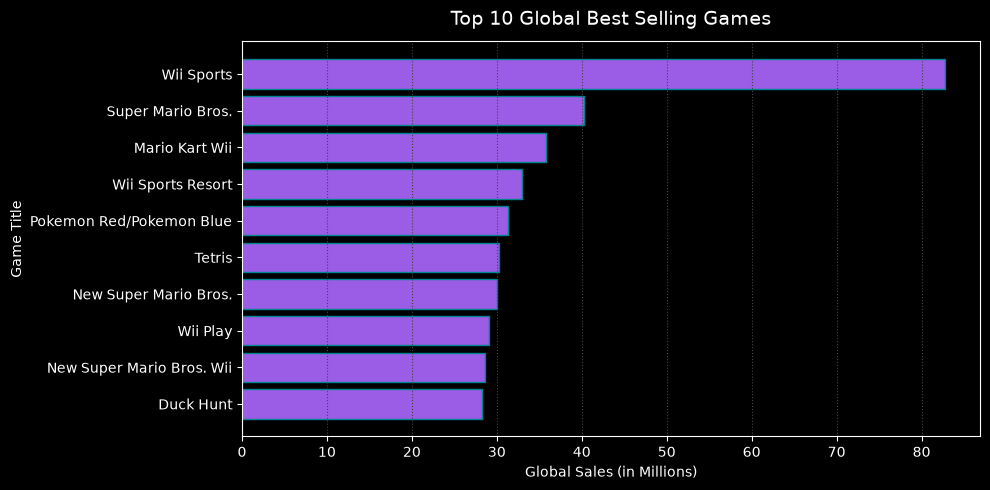

In [20]:
# Top 10 Games

top10_games = df.sort_values(by='Global_Sales', ascending=False)[['Name', 'Platform', 'Genre', 'Global_Sales']].head(10)
print(top10_games.to_string(index=False))

plt.figure(figsize=(10, 5), facecolor='black')
plt.style.use('dark_background')

plt.barh(top10_games['Name'], top10_games['Global_Sales'], color='#9B5DE5', edgecolor='#00838f')
plt.title('Top 10 Global Best Selling Games', color='white', fontsize=14, pad=12)
plt.xlabel('Global Sales (in Millions)', color='white')
plt.ylabel('Game Title', color='white')

plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle=':', color='#444444')
plt.tight_layout()
plt.show()

                      Publisher  Global_Sales
0                      Nintendo       1786.56
1               Electronic Arts       1110.32
2                    Activision        727.46
3   Sony Computer Entertainment        607.50
4                       Ubisoft        474.72
5          Take-Two Interactive        399.54
6                           THQ        340.77
7  Konami Digital Entertainment        283.64
8                          Sega        272.99
9            Namco Bandai Games        254.09


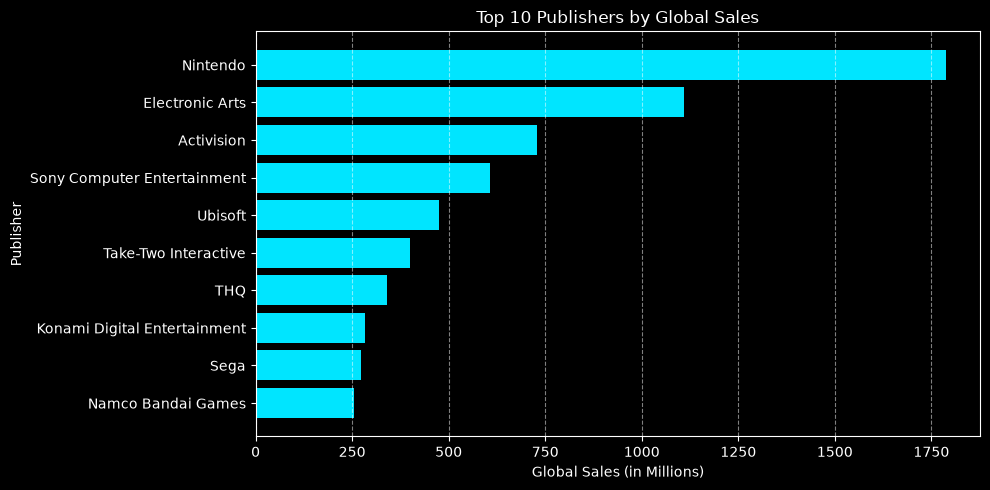

In [19]:
# Top 10 Publishers

top10_publishers = df.groupby('Publisher')['Global_Sales'].sum().nlargest(10).reset_index()
print(top10_publishers)

plt.figure(figsize=(10, 5))
plt.barh(top10_publishers['Publisher'], top10_publishers['Global_Sales'], color='#00E5FF')
plt.title('Top 10 Publishers by Global Sales', color='white', fontsize=12)
plt.xlabel('Global Sales (in Millions)', color='white')
plt.ylabel('Publisher', color='white')

plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

  Platform  Global_Sales
0      PS2       1233.46
1     X360        969.61
2      PS3        949.35
3      Wii        909.81
4       DS        818.96
5       PS        727.39
6      GBA        313.56
7      PSP        291.71
8      PS4        278.10
9       PC        255.05


<Figure size 1000x500 with 0 Axes>

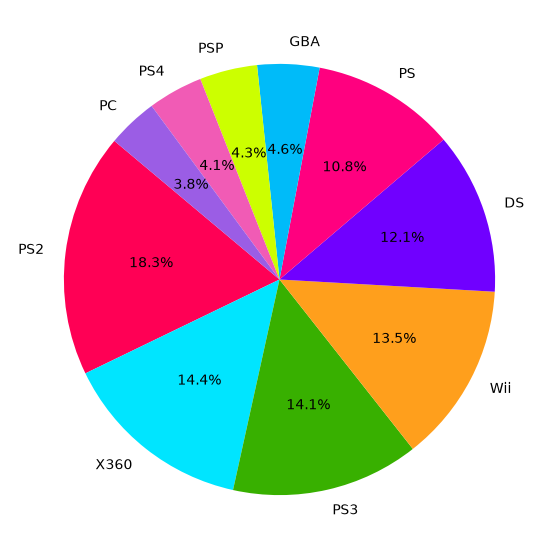

In [32]:
# Top 10 Platforms

top10_platforms = df.groupby('Platform')['Global_Sales'].sum().nlargest(10).reset_index()
print(top10_platforms)

plt.style.use('default')
plt.figure(figsize=(10, 5))

platform_colors = [
    '#FF0055', '#00E5FF', '#38B000', '#FF9F1C', '#7000FF',
    '#FF007F', '#00BBF9', '#CCFF00', '#F15BB5', '#9B5DE5'
]
plt.figure(figsize=(7, 7))
plt.pie(
    top10_platforms['Global_Sales'], 
    labels=top10_platforms['Platform'], 
    colors=platform_colors,
    autopct='%1.1f%%',
    startangle=140,
    textprops={'color': 'black'}
)

plt.show()

          Genre  Global_Sales
0        Action       1722.88
1        Sports       1309.24
2       Shooter       1026.20
3  Role-Playing        923.84
4      Platform        829.15
5          Misc        797.62
6        Racing        726.77
7      Fighting        444.05
8    Simulation        390.16
9        Puzzle        242.22


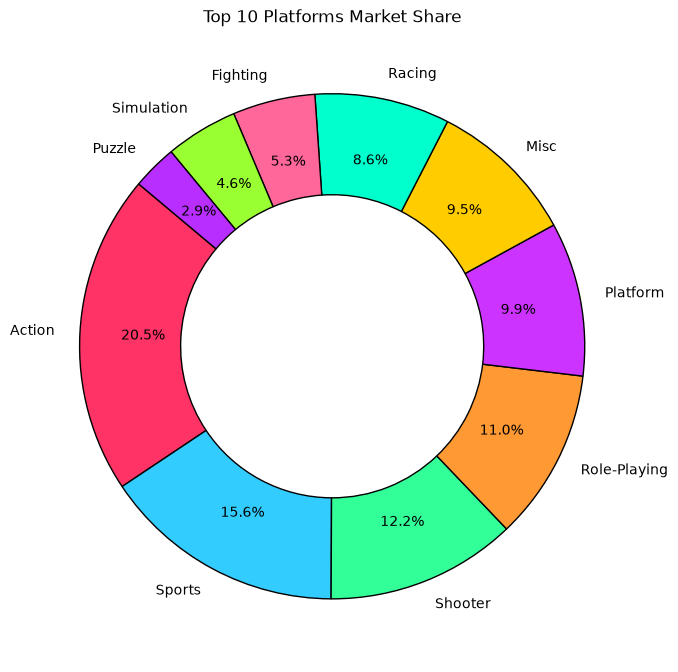

In [34]:
# Top 10 Genres

top10_genres = df.groupby('Genre')['Global_Sales'].sum().nlargest(10).reset_index()
print(top10_genres)

plt.figure(figsize=(7, 7))
colors = [
    '#FF3366', '#33CCFF', '#33FF99', '#FF9933', '#CC33FF',
    '#FFCC00', '#00FFCC', '#FF6699', '#99FF33', '#B82EFF'
]
plt.pie(
    top10_genres['Global_Sales'], 
    labels=top10_genres['Genre'], 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors,
    pctdistance=0.75,
    textprops={'color': 'black', 'fontsize': 10},
    wedgeprops=dict(width=0.4, edgecolor='black')
)

plt.title('Top 10 Platforms Market Share', color='black', fontsize=12)

plt.tight_layout()
plt.show()

8820.360000000002
North America Share: 49.13%
Europe Share: 27.31%
Japan Share: 14.56%


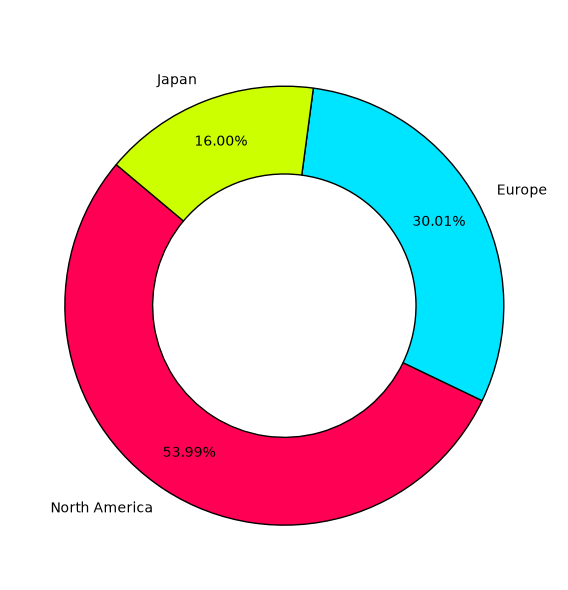

In [35]:
# Regional Sales

total_global = df['Global_Sales'].sum()
print(total_global)

na_share = (df['NA_Sales'].sum() / total_global) * 100
eu_share = (df['EU_Sales'].sum() / total_global) * 100
jp_share = (df['JP_Sales'].sum() / total_global) * 100
print(f"North America Share: {na_share:.2f}%")
print(f"Europe Share: {eu_share:.2f}%")
print(f"Japan Share: {jp_share:.2f}%")

regional_totals = [df['NA_Sales'].sum(), df['EU_Sales'].sum(), df['JP_Sales'].sum()]
regions = ['North America', 'Europe', 'Japan']

pie_colors = ['#FF0055', '#00E5FF', '#CCFF00']

plt.figure(figsize=(6, 6))
plt.pie(
    regional_totals , 
    labels=regions, 
    autopct='%1.2f%%',
    pctdistance=0.8,
    startangle=140, 
    colors=pie_colors,
    textprops={'color': 'black'},
    wedgeprops=dict(width=0.4, edgecolor='black')
)

plt.title('Regional Sales Share (NA, EU, JP)', color='white', fontsize=12)

plt.tight_layout()
plt.show()

                          Name  Global_Sales
                    Wii Sports         82.74
            Grand Theft Auto V         55.92
             Super Mario Bros.         45.31
                        Tetris         35.84
                Mario Kart Wii         35.82
             Wii Sports Resort         33.00
      Pokemon Red/Pokemon Blue         31.37
Call of Duty: Modern Warfare 3         30.83
         New Super Mario Bros.         30.01
    Call of Duty: Black Ops II         29.72


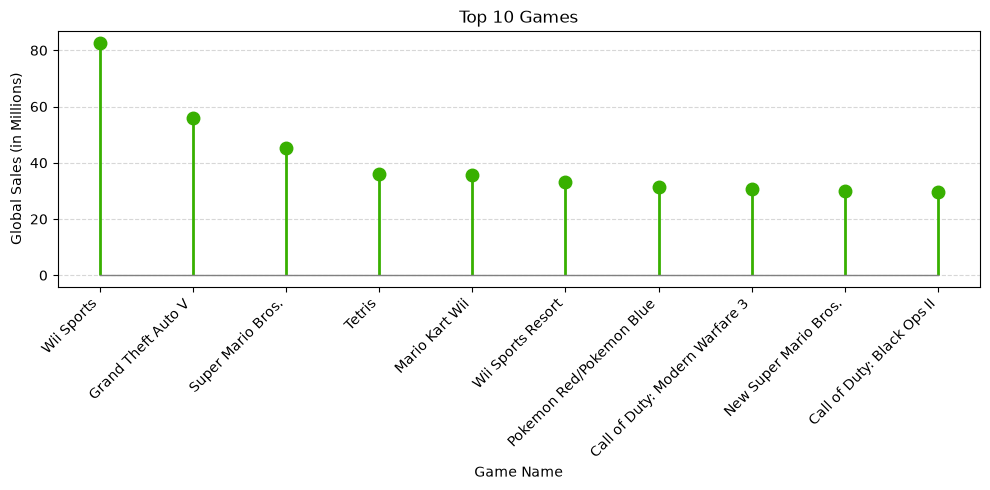

In [36]:
# Top 10 Games according to The Sales

name_sales = df.groupby('Name')['Global_Sales'].sum().nlargest(10).reset_index()
print(name_sales.to_string(index=False))


plt.figure(figsize=(10, 5))

markerline, stemlines, baseline = plt.stem(
    name_sales['Name'], 
    name_sales['Global_Sales']
)

plt.setp(markerline, color='#38B000', markersize=9)
plt.setp(stemlines, color='#38B000', linewidth=2)
plt.setp(baseline, color='gray', linewidth=1)

plt.title('Top 10 Games', fontsize=12)
plt.xlabel('Game Name')
plt.ylabel('Global Sales (in Millions)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

     Year  Total_Sales  Total_Games
0  1980.0        11.38            9
1  1981.0        35.77           46
2  1982.0        28.86           36
3  1983.0        16.79           17
4  1984.0        50.36           14


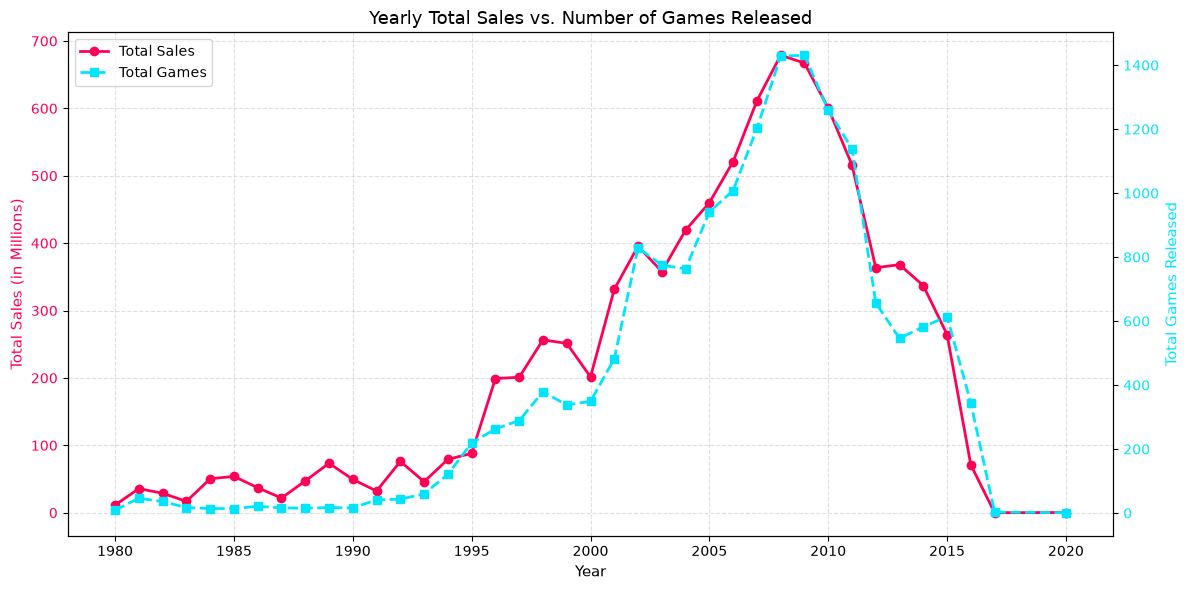

In [22]:
# Calculating both total sales and the total number of games released by year

yearly_summary = df.groupby('Year').agg(
    Total_Sales=('Global_Sales', 'sum'),
    Total_Games=('Name', 'count')
).reset_index()
print(yearly_summary.head())

fig, ax1 = plt.subplots(figsize=(12, 6))

color1 = '#FF0055'
ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Total Sales (in Millions)', color=color1, fontsize=11)
line1 = ax1.plot(yearly_summary['Year'], yearly_summary['Total_Sales'], color=color1, marker='o', linewidth=2, label='Total Sales')
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx() 
color2 = '#00E5FF'
ax2.set_ylabel('Total Games Released', color=color2, fontsize=11)
line2 = ax2.plot(yearly_summary['Year'], yearly_summary['Total_Games'], color=color2, marker='s', linestyle='--', linewidth=2, label='Total Games')
ax2.tick_params(axis='y', labelcolor=color2)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title('Yearly Total Sales vs. Number of Games Released', fontsize=13)
ax1.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [9]:
genre_regional = df.groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Global_Sales']].sum()
genre_regional['NA_%'] = (genre_regional['NA_Sales'] / genre_regional['Global_Sales']) * 100
genre_regional['EU_%'] = (genre_regional['EU_Sales'] / genre_regional['Global_Sales']) * 100
genre_regional['JP_%'] = (genre_regional['JP_Sales'] / genre_regional['Global_Sales']) * 100
print(genre_regional)

genre_shares = genre_regional[['NA_%', 'EU_%', 'JP_%']].reset_index()
print(genre_shares.to_string(index=False))

              NA_Sales  EU_Sales  JP_Sales  Global_Sales       NA_%  \
Genre                                                                 
Action          877.83    525.00    159.95       1751.18  50.127914   
Adventure       105.80     64.13     52.07        239.04  44.260375   
Fighting        223.59    101.32     87.35        448.91  49.807311   
Misc            410.24    215.98    107.76        809.96  50.649415   
Platform        447.05    201.63    130.77        831.37  53.772688   
Puzzle          123.78     50.78     57.31        244.95  50.532762   
Racing          359.42    238.39     56.69        732.04  49.098410   
Role-Playing    327.28    188.06    352.31        927.37  35.291200   
Shooter         582.60    313.27     38.28       1037.37  56.161254   
Simulation      183.31    113.38     63.70        392.20  46.738909   
Sports          683.35    376.85    135.37       1330.93  51.343797   
Strategy         68.70     45.34     49.46        175.12  39.230242   

     

  Year  Global_Sales
1980.0         11.38
1981.0         35.77
1982.0         28.86
1983.0         16.79
1984.0         50.36
1985.0         53.94
1986.0         37.07
1987.0         21.74
1988.0         47.22
1989.0         73.45
1990.0         49.39
1991.0         32.23
1992.0         76.16
1993.0         45.98
1994.0         79.17
1995.0         88.11
1996.0        199.15
1997.0        200.98
1998.0        256.47
1999.0        251.27
2000.0        201.56
2001.0        331.47
2002.0        395.52
2003.0        357.85
2004.0        419.31
2005.0        459.94
2006.0        521.04
2007.0        611.13
2008.0        678.90
2009.0        667.30
2010.0        600.45
2011.0        515.99
2012.0        363.54
2013.0        368.11
2014.0        337.05
2015.0        264.44
2016.0         70.93


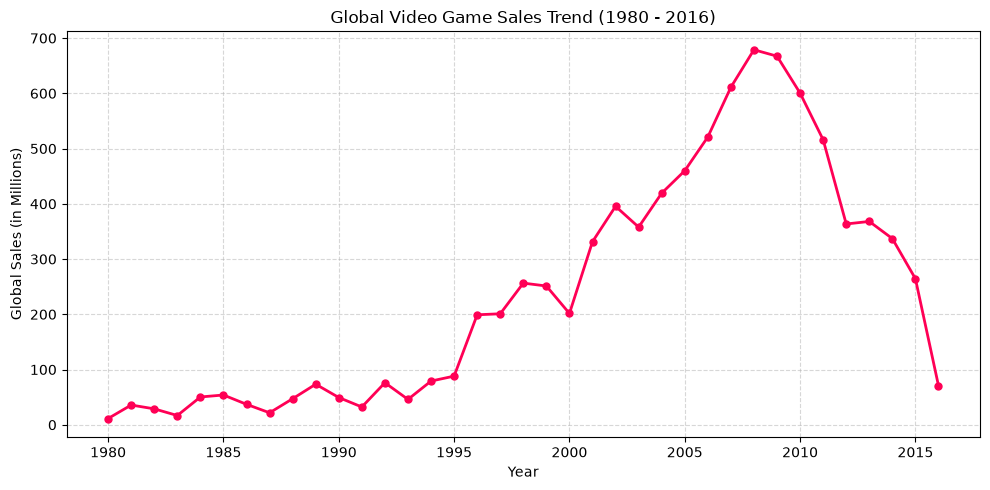

In [23]:
# Global Video Game Sales Trend (1980–2016)

yearly_trend = df[(df['Year'] >= 1980) & (df['Year'] <= 2016)].groupby('Year')['Global_Sales'].sum().reset_index()

print(yearly_trend.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.plot(
    yearly_trend['Year'], 
    yearly_trend['Global_Sales'], 
    color='#FF0055', 
    marker='o', 
    linewidth=2,
    markersize=5
)

plt.title('Global Video Game Sales Trend (1980 - 2016)', fontsize=12)
plt.xlabel('Year', fontsize=10)
plt.ylabel('Global Sales (in Millions)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Decade  Global_Sales
   80s      1.836976
   90s      0.722956
 2000s      0.504346
 2010s      0.489961
 Other      0.369299


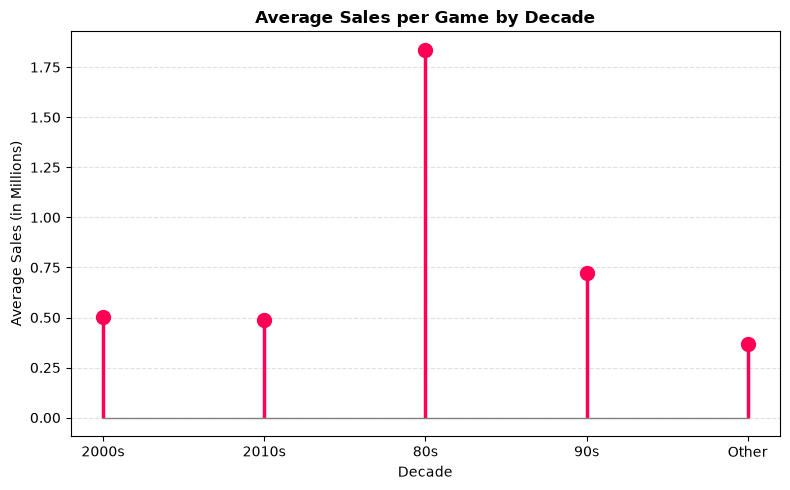

In [25]:
# Average sales per decade

def get_decade(year):
    if 1980 <= year < 1990:
        return '80s'
    elif 1990 <= year < 2000:
        return '90s'
    elif 2000 <= year < 2010:
        return '2000s'
    elif 2010 <= year <= 2020:
        return '2010s'
    return 'Other'

df['Decade'] = df['Year'].apply(get_decade)

decade_avg_sales = df.groupby('Decade')['Global_Sales'].mean().reset_index()
decade_avg_sales = decade_avg_sales.sort_values(by='Global_Sales', ascending=False)

print(decade_avg_sales.to_string(index=False))

decade_avg_sales = decade_avg_sales.sort_values(by='Decade')

plt.figure(figsize=(8, 5))

markerline, stemlines, baseline = plt.stem(
    decade_avg_sales['Decade'], 
    decade_avg_sales['Global_Sales']
)
plt.setp(markerline, color='#FF0055', markersize=10)
plt.setp(stemlines, color='#FF0055', linewidth=2.5) 
plt.setp(baseline, color='gray', linewidth=1)

plt.title('Average Sales per Game by Decade', fontsize=12, fontweight='bold')
plt.xlabel('Decade')
plt.ylabel('Average Sales (in Millions)')
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

       Genre   Region  Sales
      Action NA_Sales 877.83
    Platform NA_Sales 447.05
Role-Playing NA_Sales 327.28
     Shooter NA_Sales 582.60
      Sports NA_Sales 683.35
      Action EU_Sales 525.00
    Platform EU_Sales 201.63
Role-Playing EU_Sales 188.06
     Shooter EU_Sales 313.27
      Sports EU_Sales 376.85
      Action JP_Sales 159.95
    Platform JP_Sales 130.77
Role-Playing JP_Sales 352.31
     Shooter JP_Sales  38.28
      Sports JP_Sales 135.37


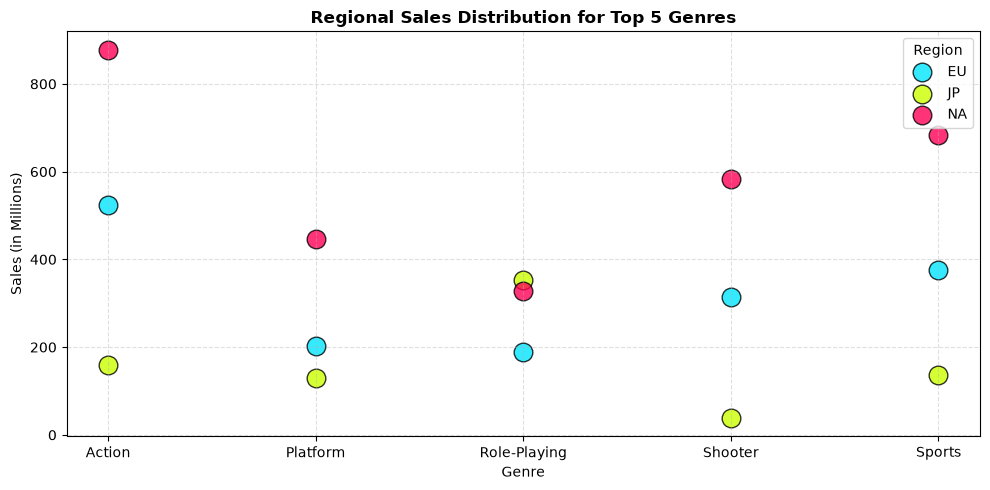

In [26]:
# Top 5 genres list
top5_genres_list = df.groupby('Genre')['Global_Sales'].sum().nlargest(5).index
top5_genres_df = df[df['Genre'].isin(top5_genres_list)].groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales']].sum().reset_index()
top5_melted = top5_genres_df.melt(id_vars='Genre', var_name='Region', value_name='Sales')

print(top5_melted.to_string(index=False))

colors = {'NA_Sales': '#FF0055', 'EU_Sales': '#00E5FF', 'JP_Sales': '#CCFF00'}

plt.figure(figsize=(10, 5))

for region, group in top5_melted.groupby('Region'):
    plt.scatter(
        group['Genre'], 
        group['Sales'], 
        label=region.replace('_Sales', ''), 
        color=colors[region], 
        s=180, 
        edgecolor='black',
        alpha=0.8
    )
plt.title('Regional Sales Distribution for Top 5 Genres', fontsize=12, fontweight='bold')
plt.xlabel('Genre', fontsize=10)
plt.ylabel('Sales (in Millions)', fontsize=10)
plt.legend(title='Region')
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [27]:
def check_sales(sales):
    if sales > 10:
        return 'Hit'
    return 'Normal'

df['Game_Type'] = df['Global_Sales'].apply(check_sales)

print(df[['Name', 'Global_Sales', 'Game_Type']].head(10).to_string(index=False))

                     Name  Global_Sales Game_Type
               Wii Sports         82.74       Hit
        Super Mario Bros.         40.24       Hit
           Mario Kart Wii         35.82       Hit
        Wii Sports Resort         33.00       Hit
 Pokemon Red/Pokemon Blue         31.37       Hit
                   Tetris         30.26       Hit
    New Super Mario Bros.         30.01       Hit
                 Wii Play         29.02       Hit
New Super Mario Bros. Wii         28.62       Hit
                Duck Hunt         28.31       Hit
